# Simplification, Speed and Splits

In [1]:
import pandas as pd 
import geopandas as gpd 
import movingpandas as mpd 
import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np
#from shapely.geometry import Point, LineString, Polygon
from shapely.geometry import Polygon
from datetime import datetime, timedelta
#from geopandas.tools import reverse_geocode, geocode
import warnings
warnings.filterwarnings('ignore')

In [231]:
def t_plot(traj, 
            figsize=(8,5), 
            source=ctx.providers.Esri.NatGeoWorldMap, 
            title=None, 
            column=None
            ):
    sport = 'Bike Ride' if traj.df.Sport[0] == 1 else 'Walk'
    f, ax = plt.subplots(figsize=figsize)
    if column:
        traj.plot(ax=ax, lw=3, column=column, 
                  cmap='inferno', legend=True)
    else:
        traj.plot(ax=ax, lw=3, color='cyan')
    ctx.add_basemap(ax, crs=traj.crs, 
                    source=source)
    ax.set_axis_off()
    if title: 
        ax.set_title(title)
    else:
        ax.set_title(f'{sport} in {traj.df.Name[0]} on {traj.df.index[0].strftime('%x')}')
    return f, ax

In [156]:
annot_props = dict(
    xytext=(3, 1), 
    textcoords="offset fontsize", 
    c='r', weight='bold', ha='center',
    arrowprops=dict(arrowstyle='-', ec='orange')
)

In [176]:
df = pd.read_csv('data/b4/combined.csv')
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(x=df.Lon, y=df.Lat), 
    crs=4269
).to_crs(32113)
idList = list(gdf.groupby(['Id']).nunique().reset_index().Id)
for i, track in enumerate(idList):
    gdf.loc[gdf.Id == track, 'trajectory_id'] = i

gdf['Time'] = pd.to_datetime(gdf.Time)
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 84322 entries, 0 to 84321
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   Id             84322 non-null  object             
 1   Name           84322 non-null  object             
 2   Lat            84322 non-null  float64            
 3   Lon            84322 non-null  float64            
 4   Elev           84322 non-null  int64              
 5   Time           84322 non-null  datetime64[ns, UTC]
 6   Temp           84322 non-null  float64            
 7   Weather        84322 non-null  int64              
 8   Sport          84322 non-null  int64              
 9   geometry       84322 non-null  geometry           
 10  trajectory_id  84322 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(4), geometry(1), int64(3), object(2)
memory usage: 7.1+ MB


In [177]:
gdf.to_file('data/nm_trek.gpkg')

## Trajectories and Trajectory Collections

In [178]:
tc = mpd.TrajectoryCollection(
    gdf, 'trajectory_id', 
    t='Time', x='Lon', y='Lat'
)
print(tc)

TrajectoryCollection with 130 trajectories


## Summary information

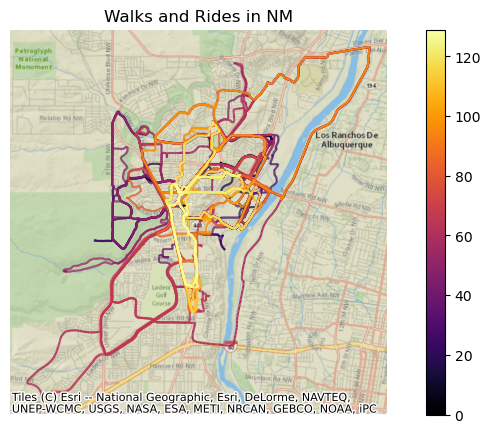

In [179]:
ax = tc.plot(
    column='trajectory_id',
    figsize=(10,5), 
    cmap='inferno', 
    legend=True
)
ax.set_title('Walks and Rides in NM')
ax.set_axis_off()
ctx.add_basemap(ax, crs=gdf.crs,
				source=ctx.providers.Esri.NatGeoWorldMap);

## Simplifying things

In [180]:
def print_intervals_size(tc):
    print(f'''
    Avg sampling interval: {(round((np.mean(
        [t.get_sampling_interval().seconds for t in tc.trajectories]
     )), 2))} seconds
    Total records: {np.sum([t.size() for t in tc.trajectories])}
     ''')
print_intervals_size(tc)


    Avg sampling interval: 5.92 seconds
    Total records: 84319
     


In [181]:
tc_generalized = (
    mpd.MinTimeDeltaGeneralizer(tc)
        .generalize(tolerance=timedelta(seconds=30))
)

In [182]:
print_intervals_size(tc_generalized)


    Avg sampling interval: 33.28 seconds
    Total records: 17258
     


In [183]:
def trek_info(traj):
    print(f'''
        Date:      {traj.get_start_time().strftime('%x')}
        Activity:  {'Bike Ride' if traj.df.Sport[0] == 1 else 'Walk'}
        Duration:  {traj.get_duration().seconds/60:.0f} minutes
        Distance:  {traj.get_length(units='mi'):.1f} miles
        Avg Speed: {((traj.get_length(units='mi')) / \
                     (traj.get_duration().seconds/60**2)):.1f} mph
        Avg Temp:  {(traj.df.Temp.mean()*9/5)+32:.0f} degrees F
        CRS:       {traj.get_crs().to_epsg()}
        Points:    {traj.size()}
        Bounds:    ({", ".join(
                          map(str,
                          [round(traj.to_crs(4269).get_bbox()[x], 3) 
                           for x in range(4)]))})

        Max Elevation: {traj.get_max(column='Elev'):,} meters
        Min Elevation: {traj.get_min(column='Elev'):,} meters
        Avg Elevation: {traj.df.Elev.mean():,.0f} meters
        
                Time         Location (Lon/Lat)
        Start: {
          traj.get_start_time().strftime('%X')
          }  {
          tuple([round(x,3) for x in 
          traj.to_crs(4269).get_start_location().coords[0]])
          } degrees
        End:   {
          traj.get_end_time().strftime('%X')
          }  {
          tuple([round(x,3) for x in
          traj.to_crs(4269).get_end_location().coords[0]])
          } degrees
    ''')


In [196]:
traj_bike = tc.trajectories[52]
traj_bike_gen = tc_generalized.trajectories[52]
trek_info(traj_bike)


        Date:      05/30/24
        Activity:  Bike Ride
        Duration:  63 minutes
        Distance:  12.1 miles
        Avg Speed: 11.5 mph
        Avg Temp:  76 degrees F
        CRS:       32113
        Points:    681
        Bounds:    (-106.714, 35.144, -106.648, 35.183)

        Max Elevation: 1,564 meters
        Min Elevation: 1,504 meters
        Avg Elevation: 1,528 meters
        
                Time         Location (Lon/Lat)
        Start: 18:41:12  (-106.708, 35.147) degrees
        End:   19:44:04  (-106.708, 35.148) degrees
    


In [185]:
trek_info(traj_bike_gen)


        Date:      05/30/24
        Activity:  Bike Ride
        Duration:  63 minutes
        Distance:  11.5 miles
        Avg Speed: 11.0 mph
        Avg Temp:  76 degrees F
        CRS:       32113
        Points:    105
        Bounds:    (-106.714, 35.144, -106.649, 35.182)

        Max Elevation: 1,562 meters
        Min Elevation: 1,504 meters
        Avg Elevation: 1,528 meters
        
                Time         Location (Lon/Lat)
        Start: 18:41:12  (-106.708, 35.147) degrees
        End:   19:44:04  (-106.708, 35.148) degrees
    


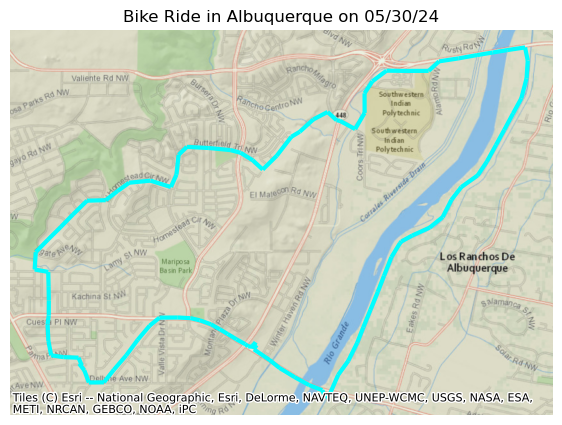

In [232]:
t_plot(traj_bike_gen);

In [187]:
traj_bike_gen.crs

<Projected CRS: EPSG:32113>
Name: NAD83 / New Mexico Central
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - New Mexico - counties of Bernalillo; Dona Ana; Lincoln; Los Alamos; Otero; Rio Arriba; Sandoval; Santa Fe; Socorro; Taos; Torrance; Valencia.
- bounds: (-107.73, 31.78, -104.84, 37.0)
Coordinate Operation:
- name: SPCS83 New Mexico Central zone (meter)
- method: Transverse Mercator
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [168]:
from itertools import chain

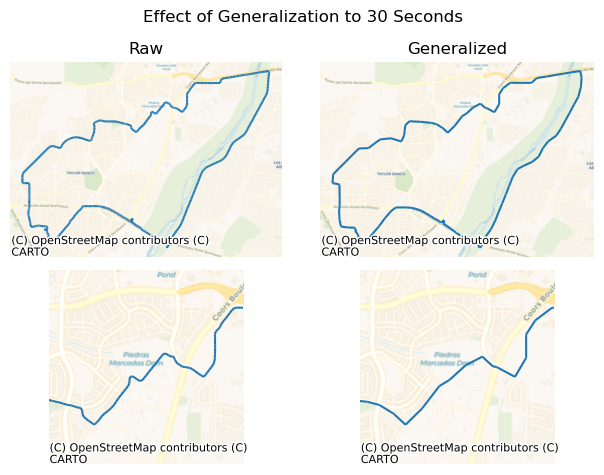

In [193]:
f, (ax1, ax2) = plt.subplots(2, 2)
for i, traj in enumerate([traj_bike, traj_bike_gen]):
    traj.plot(ax=ax1[i])
    ctx.add_basemap(ax1[i], crs=traj.crs, 
                    source=ctx.providers.CartoDB.Voyager)
for i, traj in enumerate([traj_bike, traj_bike_gen]):
    traj.plot(ax=ax2[i])
    ctx.add_basemap(ax2[i], crs=traj.crs, 
                    source=ctx.providers.CartoDB.Voyager)
    ax2[i].set_xlim(460000, 462000)
    ax2[i].set_ylim(462000, 464000)
for axs in chain(ax1, ax2): 
    axs.set_axis_off() 
ax1[0].set_title('Raw')
ax1[1].set_title('Generalized')
f.suptitle('Effect of Generalization to 30 Seconds')
f.tight_layout();

# Speed

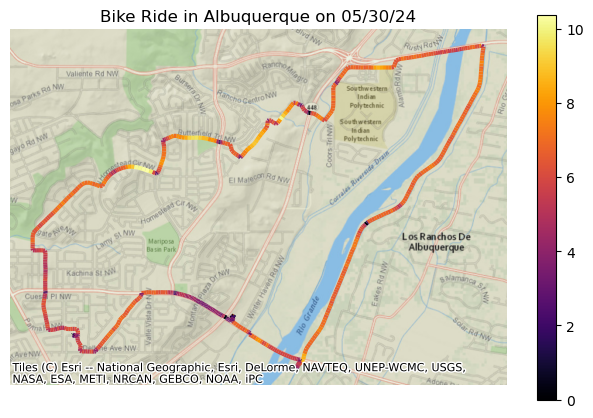

In [233]:
t_plot(traj_bike, column='speed');

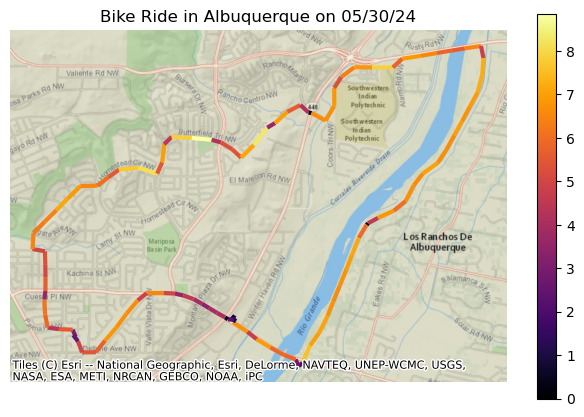

In [234]:
t_plot(traj_bike_gen, column='speed');

In [200]:
traj_bike_gen.df.columns

Index(['Id', 'Name', 'Lat', 'Lon', 'Elev', 'Temp', 'Weather', 'Sport',
       'geometry', 'trajectory_id'],
      dtype='object')

In [201]:
tc_generalized.trajectories[52].df.iloc[5]

Id                                Workout-2024-05-30-18-41-12
Name                                              Albuquerque
Lat                                                 35.150019
Lon                                                 -106.7125
Elev                                                     1536
Temp                                                     24.2
Weather                                                     0
Sport                                                       1
geometry         POINT (457860.4830821714 460313.87076766626)
trajectory_id                                            52.0
Name: 2024-05-30 18:43:54.251000, dtype: object

In [202]:
tc_generalized.add_speed()
tc_generalized.trajectories[52].df.columns

Index(['Id', 'Name', 'Lat', 'Lon', 'Elev', 'Temp', 'Weather', 'Sport',
       'geometry', 'trajectory_id', 'speed'],
      dtype='object')

In [203]:
tc_generalized.add_speed(overwrite=True, name='mi/h', units=('mi', 'h'))
tc_generalized.trajectories[52].df.iloc[5]

Id                                Workout-2024-05-30-18-41-12
Name                                              Albuquerque
Lat                                                 35.150019
Lon                                                 -106.7125
Elev                                                     1536
Temp                                                     24.2
Weather                                                     0
Sport                                                       1
geometry         POINT (457860.4830821714 460313.87076766626)
trajectory_id                                            52.0
speed                                                5.860651
mi/h                                                13.109903
Name: 2024-05-30 18:43:54.251000, dtype: object

In [204]:
tc_generalized.add_distance(overwrite=True, name="distance (km)", units="km")
tc_generalized.add_distance(overwrite=True, name="distance (mi)", units="mi")
tc_generalized.add_distance(overwrite=True, name="distance (meters)", units="m")
tc_generalized.add_distance(overwrite=True, name="distance (feet)", units="ft")
tc_generalized.add_timedelta(overwrite=True)
tc_generalized.add_speed(overwrite=True, name="speed (ft/min)", units=("ft", "min"))
tc_generalized.add_speed(overwrite=True, name="speed (km/hour)", units=("km", "h"))
tc_generalized.add_speed(overwrite=True, name="speed (mi/hour)", units=("mi", "h"))
tc_generalized.add_acceleration(
    overwrite=True, name="acceleration (mph/s)", units=("mi", "h", "s")
)
tc_generalized.add_acceleration(
    overwrite=True, name="acceleration (kmph/s)", units=("km", "h", "s")
)
tc_generalized.add_direction(overwrite=True)
tc_generalized.add_angular_difference(overwrite=True)

TrajectoryCollection with 130 trajectories

In [206]:
(tc_generalized.trajectories[52]
 .df.reset_index()
 .loc[5, 'speed':'angular_difference'])

speed                                  5.860651
mi/h                                  13.109903
distance (km)                          0.175855
distance (mi)                          0.109271
distance (meters)                     175.85469
distance (feet)                      576.951082
timedelta                0 days 00:00:30.006000
speed (ft/min)                      1153.671431
speed (km/hour)                       21.098343
speed (mi/hour)                       13.109903
acceleration (mph/s)                   0.104386
acceleration (kmph/s)                  0.167992
direction                            349.062474
angular_difference                    70.594237
Name: 5, dtype: object

In [207]:
traj_bike_gen = tc_generalized.trajectories[52]

In [208]:
print(f'''
    Total Distance: 
        {traj_bike_gen.df['distance (meters)']
            .sum().item()/1000:>4.1f} kilometers
        {traj_bike_gen.df['distance (mi)']
            .sum().item():>4.1f} miles
    Average Speed:
        {traj_bike_gen.df['speed (km/hour)']
            .mean().item():>4.1f} kilometers per hour
        {traj_bike_gen.df['speed (mi/hour)']
            .mean().item():>4.1f} miles per hour
''')



    Total Distance: 
        18.5 kilometers
        11.5 miles
    Average Speed:
        19.2 kilometers per hour
        11.9 miles per hour



In [212]:
traj_bike_gen.df['ElevD'] = (
    [traj_bike_gen.df.iloc[i].Elev - traj_bike_gen.df.iloc[i-1].Elev 
     for i in range(len(traj_bike_gen.df))]
)

In [213]:
traj_bike_gen.df.iloc[0]

Id                                        Workout-2024-05-30-18-41-12
Name                                                      Albuquerque
Lat                                                         35.147435
Lon                                                       -106.708363
Elev                                                             1540
Temp                                                             24.2
Weather                                                             0
Sport                                                               1
geometry                 POINT (458236.0978883571 460025.47489682224)
trajectory_id                                                    52.0
speed                                                        1.036478
mi/h                                                         2.318535
distance (km)                                                     0.0
distance (mi)                                                     0.0
distance (meters)   

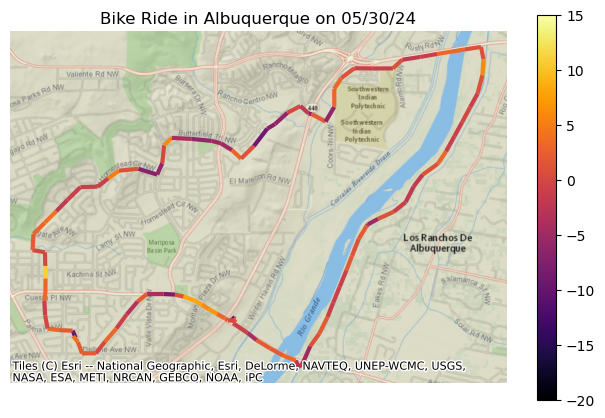

In [235]:
t_plot(traj_bike_gen, column='ElevD');

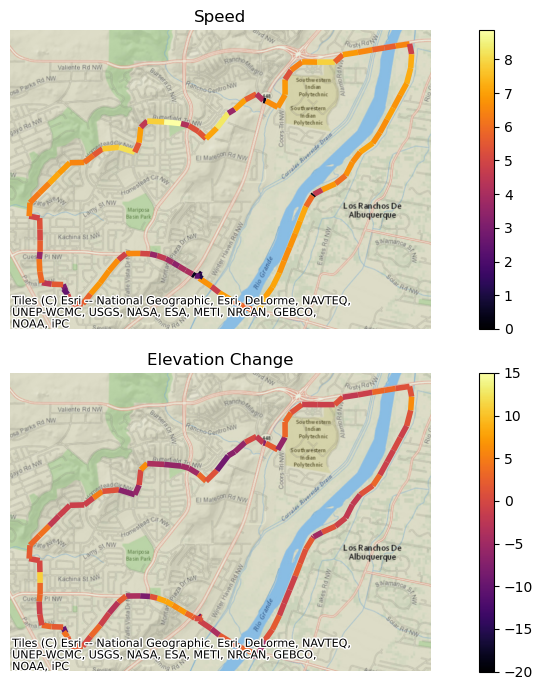

In [237]:
f, ax = plt.subplots(nrows=2, figsize=(10,7))
traj_bike_gen.plot(ax=ax[0], column='speed', 
                   cmap='inferno', legend=True, 
                  linewidth=4)
traj_bike_gen.plot(ax=ax[1], column='ElevD', 
                   cmap='inferno', legend=True, 
                  linewidth=4)
for i in range(2): 
    ctx.add_basemap(ax[i], crs=traj_bike_gen.crs, 
                   source=ctx.providers.Esri.NatGeoWorldMap)
    ax[i].set_axis_off()
ax[0].set_title('Speed')
ax[1].set_title('Elevation Change')
f.tight_layout();

# Segments

In [238]:
df_ny = gpd.read_file('data/ny_trek.gpkg')
df_ny['Sport'] = 17

```
tc_ny = mpd.TrajectoryCollection(
    df_ny, 'trajectory_id', 
    t='Time', x='Lon', y='Lat'
)
print(tc_ny)
```

In [239]:
ny_walk = (
    mpd.TrajectoryCollection(
    df_ny, 'trajectory_id', 
    t='Time', x='Lon', y='Lat'
    ).trajectories[0])

In [241]:
split_stop = (mpd.StopSplitter(ny_walk)
              .split(
                min_duration = timedelta(seconds=120), 
                max_diameter = 100
))
split_stop

TrajectoryCollection with 18 trajectories

In [243]:
%%capture
split_time = (mpd.TemporalSplitter(ny_walk)
             .split(mode='hour'));

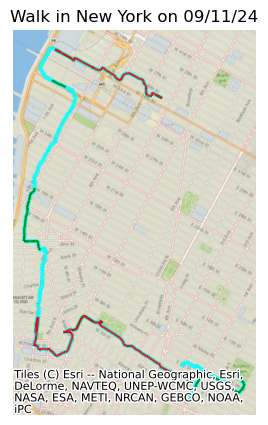

In [252]:
f, ax = t_plot(ny_walk)
for i in range(0,len(split_stop),2): 
    split_stop.trajectories[i].plot(ax=ax, color='g')
for i in range(0,len(split_time),2): 
    split_time.trajectories[i].plot(ax=ax, color='r')

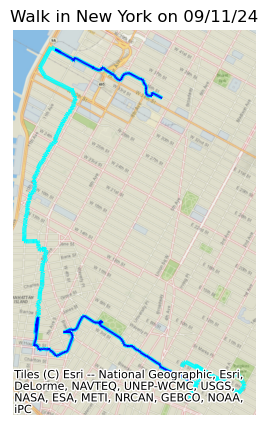

In [245]:
f, ax = t_plot(ny_walk)
for i in range(0,len(split_time),2): 
    split_time.trajectories[i].plot(ax=ax, color='b')

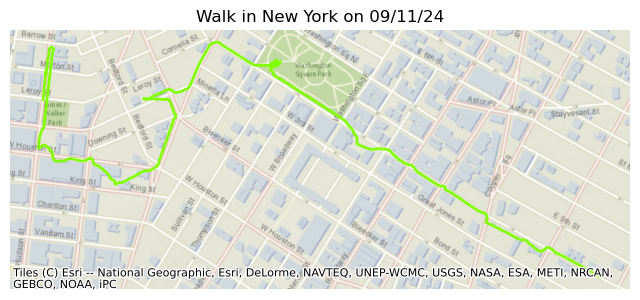

In [39]:
t1 = datetime(2024, 9, 11, 19) # UTC Time
t2 = t1 + timedelta(minutes=60)
segment = ny_walk.get_segment_between(t1,t2)
t_plot(segment);

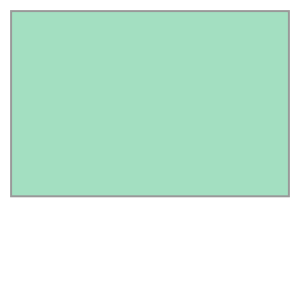

In [40]:
xmin, xmax, ymin, ymax = 191000, 192500, 210000, 211000
polygon = Polygon(
    [(xmin, ymin), (xmin, ymax), (xmax, ymax), (xmax, ymin), (xmin, ymin)]
)
polygon

In [41]:
intersections = ny_walk.clip(polygon) 

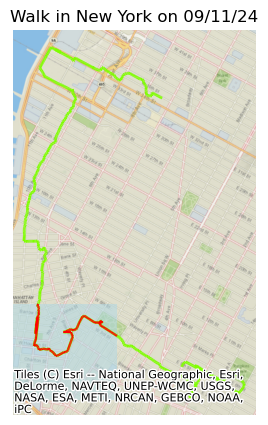

In [42]:
f, ax = t_plot(ny_walk)
gpd.GeoSeries(polygon).plot(ax=ax, color='lightblue', 
                           alpha=0.5)
intersections.plot(ax=ax, color='r');